In [58]:
import sys
import pandas as pd
import seaborn 
!uv pip install scipy --python {sys.executable}
from scipy import stats
!uv pip install numpy --python {sys.executable}
import numpy as np

Audited 1 package in 3ms
Audited 1 package in 2ms


In [59]:
immunizations = pd.read_csv('immunizations.csv')

In [60]:
immunizations

,School,City,Adequately immunized %,Exempt %,Conditionally enrolled %,Extended conditionally enrolled %,Out of compliance %,District/LEA,Grades,Address,Zip,Map,school_type
0,river rock school,lehi,89.7,10.3,0.0,0.0,0.0,Alpine District,Pre - 6,520 North 1700 West,84043,"geo:40.3937097,-111.8764976",Public
1,springside school,saratoga springs,82.9,13.7,0.9,0.9,1.7,Alpine District,Pre - 6,694 South Highpoint Drive,84045,"geo:40.3494704,-111.9152738",Public
2,american preparatory academy,draper,92.0,7.0,1.0,0.0,0.0,American Preparatory Academy,K - 6,12892 S PONY EXPRESS RD,84020,"geo:40.517489,-111.891825",Charter
3,ascent academies of utah lehi,lehi,87.0,13.0,0.0,0.0,0.0,Ascent Academies of Utah,K - 9,2199 W 900 N,84043,"geo:40.3986691,-111.8870765",Charter
4,birch creek school,smithfield,93.0,5.3,0.9,0.0,0.9,Cache District,Pre - 6,675 W 220 N,84335,"geo:41.842084,-111.852014",Public
...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,silver lake elementary,eagle mountain,84.5,15.5,0.0,0.0,0.0,Alpine District,Pre - 6,5069 Golden Eagle Road,84005,"geo:40.350111,-111.96156",Public
514,sunburst school,layton,90.2,7.3,0.0,1.6,0.8,Davis District,Pre - 6,2504 W Sunburst Drive,84041,"geo:41.06016,-112.01109",Public
515,trailside elementary,vineyard,86.1,7.9,0.0,6.0,0.0,Alpine District,Pre - 6,452 N Vineyard Loop Road,84058,"geo:40.30451,-111.74758",Public
516,twenty wells elementary,grantsville,94.0,6.0,0.0,0.0,0.0,Tooele District,Pre - 6,636 E Nygreen,84029,"geo:40.5783,-112.43632",Public


<Axes: xlabel='school_type', ylabel='Adequately immunized %'>

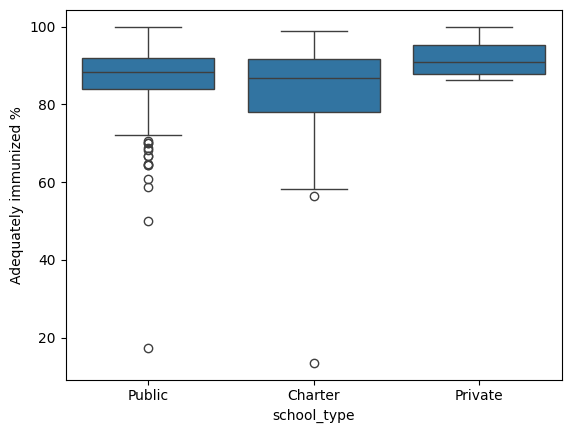

In [ ]:
seaborn.boxplot(data=immunizations, x='school_type', y='Adequately immunized %')

<Axes: xlabel='Adequately immunized %', ylabel='Count'>

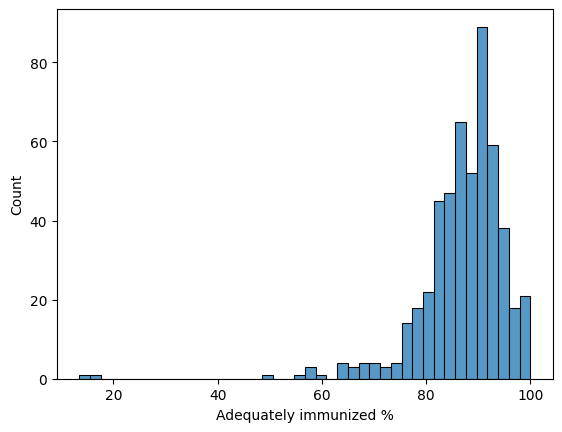

In [62]:
seaborn.histplot(data = immunizations, x = 'Adequately immunized %')

In [ ]:
charter_priv = immunizations[immunizations['school_type'].isin(['Charter', 'Private'])]['Adequately immunized %']
public = immunizations[immunizations['school_type'] == 'Public']['Adequately immunized %']
immunizations['non_trad'] = immunizations['school_type'].isin(['Charter', 'Private']).astype(int)


/tmp/ipykernel_14707/999292610.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn.boxplot(data=immunizations, x='non_trad', y='Adequately immunized %', palette=['lightblue', 'pink'],)
/tmp/ipykernel_14707/999292610.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Public School', 'Private or Charter School'])


Text(0.5, 0, '')

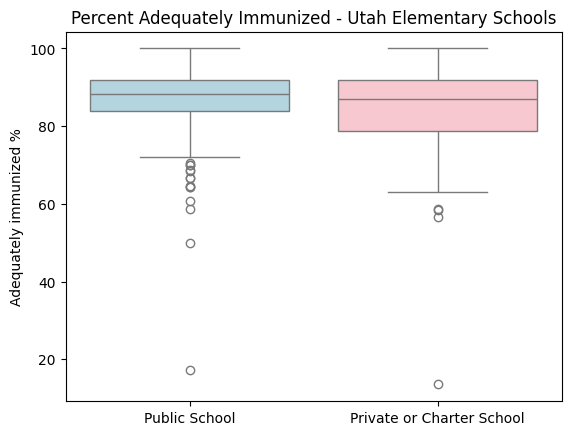

In [66]:
ax = seaborn.boxplot(data=immunizations, x='non_trad', y='Adequately immunized %', palette=['lightblue', 'pink'],)

ax.set_xticklabels(['Public School', 'Private or Charter School'])
ax.set_title('Percent Adequately Immunized - Utah Elementary Schools')
ax.set_xlabel('')

/tmp/ipykernel_14707/638756077.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn.violinplot(data=immunizations, x='non_trad', y='Adequately immunized %', palette=['lightblue', 'pink'],)
/tmp/ipykernel_14707/638756077.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Public School', 'Private or Charter School'])


Text(0.5, 0, '')

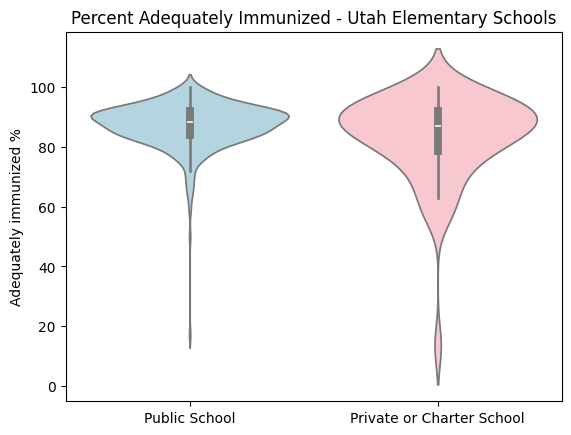

In [67]:
ax = seaborn.violinplot(data=immunizations, x='non_trad', y='Adequately immunized %', palette=['lightblue', 'pink'],)

ax.set_xticklabels(['Public School', 'Private or Charter School'])
ax.set_title('Percent Adequately Immunized - Utah Elementary Schools')
ax.set_xlabel('')

In [ ]:
statistic, p_value = stats.shapiro(public)

print(f"Shapiro-Wilk Statistic: {statistic}")
print(f"P-value: {p_value}")

Shapiro-Wilk Statistic: 0.8492893076003255
P-value: 1.247757321701608e-20


In [69]:
print('nontrad variance', charter_priv.var(), 'public school variance', public.var())

nontrad variance 210.22845117845122 public school variance 56.69208035305227


In [73]:
stat, p_val = stats.levene(public, charter_priv)
print(f"Levene's P-value: {p_val}") 

Levene's P-value: 4.744105060651353e-06
